# 04-Distributed Joins & Broadcast Physics

In Lesson 03, we analyzed the physics of the Network Shuffle. We proved that Wide Dependencies introduce an $\mathcal{O}(N \times M)$ cross-talk penalty that forces data serialization and halts Executor CPU cycles.

The absolute pinnacle of Shuffle complexity occurs when you execute a **Distributed Join** (`dfA.join(dfB)`). If two massive datasets are randomly partitioned across a 100-node cluster, Spark must physically shuffle *both* tables across the network using a matching join key hash to ensure related rows land on the same JVM. This is known as a **Shuffle Hash Join** or **Sort-Merge Join**, and it represents the single greatest latency hotspot in Big Data platforms.

However, in Enterprise data warehousing, we routinely join a massive, multi-billion-row **Fact Table** (e.g., `fact_sales`) against a tiny, 100-row **Dimension Table** (e.g., `dim_store_locations`). Shuffling billions of rows just to match them against 100 static rows is an engineering failure.

To bypass this bottleneck completely, we can alter the network topology using **Broadcast Physics**.

Let's set up our cluster environment to eliminate the Join Shuffle.

In [8]:
# Required installations: pip install pyspark matplotlib seaborn
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Broadcast Optimization Engine Operational.")

✅ Systems Architecture & Broadcast Optimization Engine Operational.


# 1. The Mathematics of Join Topologies

Let $\mathbf{T}_{fact}$ be a massive Fact DataFrame sharded into $N$ partitions across the cluster, and let $\mathbf{T}_{dim}$ be a minor Dimension DataFrame sharded into $M$ partitions.

### The Sort-Merge Join (Standard Network Shuffle)

If we execute a standard join, Spark must realign both tables. The time complexity is bounded by the sorting and network transfer of both sets:


$$\text{Complexity} = \mathcal{O}(|T_{fact}| \log|T_{fact}| + |T_{dim}| \log|T_{dim}|) + \text{NetworkShuffle}(T_{fact} + T_{dim})$$


Because $|T_{fact}|$ is massive, the network I/O cost dominates the total pipeline duration.

### The Broadcast Hash Join ($\mathcal{O}(1)$ Network Shuffle for Fact Table)

If $|T_{dim}|$ is small enough to fit entirely within the RAM of a single executor, we can invoke a **Broadcast Hash Join (BHJ)**.

The physics shift completely:

1. The Driver node pulls the *entirety* of $\mathbf{T}_{dim}$ out of the worker partitions and brings it into its localized RAM.
2. The Driver serializes $\mathbf{T}_{dim}$ into a highly efficient lookup hash map.
3. The Driver broadcasts a **complete copy** of this hash map to *every single Executor* in the cluster via a point-to-multipoint network protocol.
4. The Executors map the local partitions of $\mathbf{T}_{fact}$ against the local broadcasted hash map.

The mathematical complexity drops to:


$$\text{Complexity} = \mathcal{O}(|T_{fact}|) + \text{NetworkTransfer}(|\mathcal{W}| \times |T_{dim}|)$$


Where $|\mathcal{W}|$ is the number of worker nodes. Because $|T_{fact}|$ never leaves its localized data blocks, the Network Shuffle penalty drops to **zero**.

# 2. Architecting the Sort-Merge vs. Broadcast Comparison

Let's write two competing distributed join pipelines inside PySpark. We will force a traditional Sort-Merge Join, inspect its plan, and then use `F.broadcast()` to convert it into a zero-shuffle Broadcast Hash Join.

In [9]:
# --- ⚙️ STEP 1: Booting the Cluster ---
spark = SparkSession.builder \
    .appName("Broadcast_Physics") \
    .master("local[4]") \
    .config("spark.sql.adaptive.enabled", "false") \
    .getOrCreate() # Turn off AQE to observe raw, manual physics

# --- 📦 STEP 2: Creating the Imbalanced Matrices ---
print("--- 🚀 Generating Simulated Fact and Dimension Data ---")

# 1. The Massive Fact Table (e.g., 5 Million Transaction Logs)
fact_transactions = spark.range(0, 5000000).withColumn("product_id", (F.col("id") % 100))

# 2. The Tiny Dimension Table (e.g., 5 Product Categories)
dim_products = spark.createDataFrame([
    (0, "AI Accelerator GPU"),
    (1, "High-Bandwidth Memory"),
    (2, "Optic Fiber Switch Transceiver")
], ["product_id", "product_name"])

print(f"Fact Table Partition Count: {fact_transactions.rdd.getNumPartitions()}")
print(f"Dim Table Partition Count: {dim_products.rdd.getNumPartitions()}")

--- 🚀 Generating Simulated Fact and Dimension Data ---
Fact Table Partition Count: 4
Dim Table Partition Count: 4


### Execution A: The Naive Sort-Merge Join

We will join the tables natively. Watch how Spark compiles a dual-sided network exchange.

In [10]:
print("\n--- 🛑 Pipeline A: Executing Standard Sort-Merge Join ---")

standard_join_df = fact_transactions.join(dim_products, "product_id")

# Force the plan to compile by requesting an explanation
standard_join_df.explain()



--- 🛑 Pipeline A: Executing Standard Sort-Merge Join ---
== Physical Plan ==
*(5) Project [product_id#5L, id#4L, product_name#7]
+- *(5) SortMergeJoin [product_id#5L], [product_id#6L], Inner
   :- *(2) Sort [product_id#5L ASC NULLS FIRST], false, 0
   :  +- Exchange hashpartitioning(product_id#5L, 200), ENSURE_REQUIREMENTS, [plan_id=165]
   :     +- *(1) Project [id#4L, (id#4L % 100) AS product_id#5L]
   :        +- *(1) Filter isnotnull((id#4L % 100))
   :           +- *(1) Range (0, 5000000, step=1, splits=4)
   +- *(4) Sort [product_id#6L ASC NULLS FIRST], false, 0
      +- Exchange hashpartitioning(product_id#6L, 200), ENSURE_REQUIREMENTS, [plan_id=171]
         +- *(3) Filter isnotnull(product_id#6L)
            +- *(3) Scan ExistingRDD[product_id#6L,product_name#7]




### Execution B: The Optimized Broadcast Hash Join

Now, we inject `F.broadcast()` around our dimension table. This tells the Catalyst Compiler to bypass the traditional shuffle layout completely.

In [11]:
print("\n--- 🟢 Pipeline B: Executing Optimized Broadcast Hash Join ---")

# We wrap the light side-car dataframe in the broadcast macro
optimized_join_df = fact_transactions.join(F.broadcast(dim_products), "product_id")

optimized_join_df.explain()

print("\n--- 💡 Engineering Insight ---")
print("Look at the physical plans side-by-side.")
print("In Pipeline A, you see two independent 'Exchange hashpartitioning' nodes. Both tables are being fully serialized and pushed across the virtual network switch.")
print("In Pipeline B, the 'Exchange' node on the massive Fact table completely vanishes. Instead, you see a single 'BroadcastExchange' node applied exclusively to the tiny product list. The Fact table is read natively from RAM via a 'WholeStageCodegen' vector scan, completely eliminating network contention.")


--- 🟢 Pipeline B: Executing Optimized Broadcast Hash Join ---
== Physical Plan ==
*(2) Project [product_id#5L, id#4L, product_name#7]
+- *(2) BroadcastHashJoin [product_id#5L], [product_id#6L], Inner, BuildRight, false
   :- *(2) Project [id#4L, (id#4L % 100) AS product_id#5L]
   :  +- *(2) Filter isnotnull((id#4L % 100))
   :     +- *(2) Range (0, 5000000, step=1, splits=4)
   +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, false]),false), [plan_id=225]
      +- *(1) Filter isnotnull(product_id#6L)
         +- *(1) Scan ExistingRDD[product_id#6L,product_name#7]



--- 💡 Engineering Insight ---
Look at the physical plans side-by-side.
In Pipeline A, you see two independent 'Exchange hashpartitioning' nodes. Both tables are being fully serialized and pushed across the virtual network switch.
In Pipeline B, the 'Exchange' node on the massive Fact table completely vanishes. Instead, you see a single 'BroadcastExchange' node applied exclusively to the tiny product l

# 3. Dynamic Thresholds: Automated Broadcast Physics

In production, you do not always need to write `F.broadcast()` manually. Spark possesses an internal configuration threshold: `spark.sql.autoBroadcastJoinThreshold`.

In [12]:
# Retrieve the system threshold parameter in bytes
threshold_str = spark.conf.get("spark.sql.autoBroadcastJoinThreshold")

current_threshold_bytes = int(threshold_str.rstrip("b"))
current_threshold_mb = current_threshold_bytes / 1024 / 1024

print(f"💡 Default Auto-Broadcast Threshold: {current_threshold_mb} MB")
print("\nIf a table's physical size on disk (as calculated by the Parquet file statistics) is less than this threshold, the Catalyst Optimizer will automatically rewrite your standard join into a Broadcast Join without any code modifications.")
print("Engineering Guardrail: In Enterprise clusters, you can increase this to 100MB or 500MB if your executors have high memory pools. Never set it to a massive value (like 5GB), or multiple parallel queries will broadcast giant tables simultaneously, triggering a fatal Executor Java heap OutOfMemory (OOM) crash.")

💡 Default Auto-Broadcast Threshold: 10.0 MB

If a table's physical size on disk (as calculated by the Parquet file statistics) is less than this threshold, the Catalyst Optimizer will automatically rewrite your standard join into a Broadcast Join without any code modifications.
Engineering Guardrail: In Enterprise clusters, you can increase this to 100MB or 500MB if your executors have high memory pools. Never set it to a massive value (like 5GB), or multiple parallel queries will broadcast giant tables simultaneously, triggering a fatal Executor Java heap OutOfMemory (OOM) crash.


# 4. Visualizing Broadcast vs. Shuffle Network Flow

To fully grasp why Broadcast Joins save immense data-center network bandwidth, let's map the physical topological routing of the two join methodologies.

/tmp/ipykernel_14226/1778041198.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0), 6, 7, fill=True, color='#e74c3c', alpha=0.08, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_14226/1778041198.py:11: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7, 0), 6, 7, fill=True, color='#2ecc71', alpha=0.08, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_14226/1778041198.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 4.5), 1.5, 1.2, fill=True, color='#3498db', edgecolor='black'))
/tmp/ipykernel_14226/1778041198.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.0, 4.5), 1.5, 1.2, fill=True, color='#9b59b6', edg

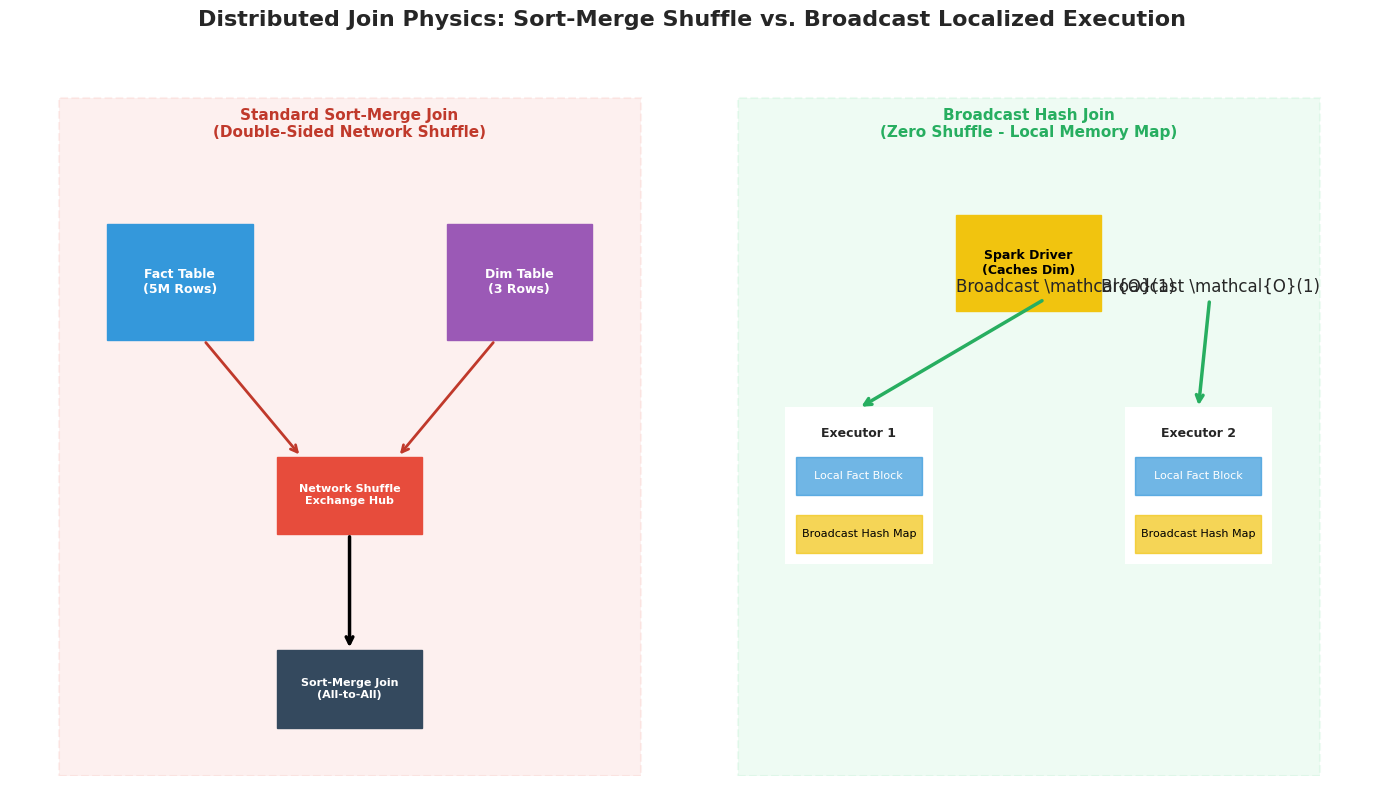

In [13]:
# Visualizing Join Network Topologies
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Distributed Join Physics: Sort-Merge Shuffle vs. Broadcast Localized Execution", fontsize=16, fontweight='bold')

ax.axis('off')

# Background Layout Zones
ax.add_patch(patches.Rectangle((0, 0), 6, 7, fill=True, color='#e74c3c', alpha=0.08, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(3, 6.6, "Standard Sort-Merge Join\n(Double-Sided Network Shuffle)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

ax.add_patch(patches.Rectangle((7, 0), 6, 7, fill=True, color='#2ecc71', alpha=0.08, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10, 6.6, "Broadcast Hash Join\n(Zero Shuffle - Local Memory Map)", ha='center', color='#27ae60', fontweight='bold', fontsize=11)


# --- LEFT PATHWAY: SORT-MERGE SHUFFLE ---
# Input Matrices
ax.add_patch(patches.Rectangle((0.5, 4.5), 1.5, 1.2, fill=True, color='#3498db', edgecolor='black'))
ax.text(1.25, 5.1, "Fact Table\n(5M Rows)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((4.0, 4.5), 1.5, 1.2, fill=True, color='#9b59b6', edgecolor='black'))
ax.text(4.75, 5.1, "Dim Table\n(3 Rows)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# The Shuffle Grid Hub
ax.add_patch(patches.Rectangle((2.25, 2.5), 1.5, 0.8, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(3.0, 2.9, "Network Shuffle\nExchange Hub", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Output Execution Join
ax.add_patch(patches.Rectangle((2.25, 0.5), 1.5, 0.8, fill=True, color='#34495e', edgecolor='black'))
ax.text(3.0, 0.9, "Sort-Merge Join\n(All-to-All)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Arrows for Shuffle path
ax.annotate("", xy=(2.5, 3.3), xytext=(1.5, 4.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b"))
ax.annotate("", xy=(3.5, 3.3), xytext=(4.5, 4.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b"))
ax.annotate("", xy=(3.0, 1.3), xytext=(3.0, 2.5), arrowprops=dict(arrowstyle="->", lw=2.5, color="black"))


# --- RIGHT PATHWAY: BROADCAST PHYSICS ---
# Driver Central Node
ax.add_patch(patches.Rectangle((9.25, 4.8), 1.5, 1.0, fill=True, color='#f1c40f', edgecolor='black'))
ax.text(10.0, 5.3, "Spark Driver\n(Caches Dim)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Distributed Executors (Localized Processing)
executors = [(7.5, 2.2, "Executor 1"), (11.0, 2.2, "Executor 2")]
for x, y, name in executors:
    ax.add_patch(patches.Rectangle((x, y), 1.5, 1.6, fill=True, color='white', edgecolor='black', linewidth=1.5))
    ax.text(x+0.75, y+1.3, name, ha='center', fontweight='bold', fontsize=9)
    
    # Internal localized pieces
    ax.add_patch(patches.Rectangle((x+0.1, y+0.7), 1.3, 0.4, fill=True, color='#3498db', alpha=0.7))
    ax.text(x+0.75, y+0.9, "Local Fact Block", ha='center', va='center', fontsize=8, color='white')
    
    ax.add_patch(patches.Rectangle((x+0.1, y+0.1), 1.3, 0.4, fill=True, color='#f1c40f', alpha=0.7))
    ax.text(x+0.75, y+0.3, "Broadcast Hash Map", ha='center', va='center', fontsize=8, color='black')

# Broadcast flow lines from Driver directly to the localized memory maps
ax.annotate("Broadcast \\mathcal{O}(1)", xy=(8.25, 3.8), xytext=(9.25, 5.0), arrowprops=dict(arrowstyle="->", lw=2.5, color='#27ae60', linestyle='-'))
ax.annotate("Broadcast \\mathcal{O}(1)", xy=(11.75, 3.8), xytext=(10.75, 5.0), arrowprops=dict(arrowstyle="->", lw=2.5, color='#27ae60', linestyle='-'))

plt.xlim(-0.5, 13.5)
plt.ylim(0, 7.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Distributed Joins like **Validating ID Badges at a Secure Military Installation**:

* **Sort-Merge Join (The Central Congestion Checkpoint)**: You have 5,000 workers arriving in 100 buses (The Fact Table). At the base entrance, there is an identification rulebook containing 3 valid security clearance codes (The Dimension Table). In a standard join, the base forces all 5,000 workers to get off their buses, combines them into a massive processing arena, and matches them one-by-one against a central ledger. The network entrance is blocked, workers stand around for hours, and the system stalls.
* **Broadcast Join (The Distributed Rulebook Copy)**: You print 100 cheap photocopies of the 3-line security code rulebook (The Broadcast Step). Before the buses even arrive, you hand exactly one copy of the rulebook to the security guard standing *inside every single bus* (The Executor Memory Cache).
* When the bus reaches its assigned sector, the local guard checks the workers' IDs right there inside the bus using the local document. The workers never step off the bus, they never crowd the main entrance gates, and the entire facility operations continue at maximum speed.

By utilizing Broadcast Joins, Data Engineers eliminate network dependencies for asymmetric tables, achieving massive optimization scaling across global computing nodes.